<a href="https://colab.research.google.com/github/suparuek2405/credit-default-dl/blob/main/notebooks/04_TabNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # 04 — TabNet for Credit Default Prediction
### UCI Credit Card Default Dataset

---

## 🎯 Goal
Beat the best results from previous notebooks using a purpose-built tabular deep learning architecture.

| Metric | Best So Far | Source |
|---|---|---|
| AUC | 0.7598 | Baseline Ensemble (NB02) |
| Recall | 68.6% | DL Final Model (NB03) |
| False Positives | 696 | Logistic Regression (NB02) |
| False Negatives | 291 | XGBoost (NB02) |

---

## 🧠 Approach: TabNet

Previous notebooks identified two key problems:

**Problem 1: NearMiss caused fast overfitting**
- Reduced training data from 17,850 → ~6,600 boundary samples
- Complex models memorized boundary cases in <10 epochs
- Val loss rose immediately while train loss kept dropping

**Problem 2: Custom MLP architecture was the wrong tool**
- All 4 architectures converged to similar AUC (~0.757)
- Adding depth and parallel paths gave marginal gains
- Data quality was the bottleneck, not model complexity

**Solution: TabNet**
TabNet (Arik & Pfister, 2021) is a deep learning architecture
specifically designed for tabular data. Key advantages:

- **Sequential attention steps:** processes features in multiple
  decision steps — each step focuses on different feature subsets
- **Sparse feature selection:** built-in regularization naturally
  prevents overfitting without NearMiss
- **No resampling needed:** handles class imbalance via pos_weight
  directly, keeping all 17,850 training samples
- **Built-in interpretability:** native feature importance per step,
  no external SHAP library needed
- **Proven on credit data:** published AUC of 0.83-0.85 on
  credit risk datasets

---

## 🔄 Pipeline

1. Full training data (17,850 samples) — no resampling
2. Feature engineering (40 features)
3. StandardScaler normalization
4. TabNet with pos_weight (class imbalance handling)
5. Optuna tuning (50-100 trials on val set)
6. Final model training with best params
7. Test set evaluation (used once, honest score)
8. Built-in feature importance + interpretation

---

## 📚 References

- Arik, S. O., & Pfister, T. (2021). **TabNet: Attentive Interpretable
  Tabular Learning.** *Proceedings of the AAAI Conference on Artificial
  Intelligence.* https://arxiv.org/abs/1908.07442

- Wang, S., & Zhang, X. (2024). **Research on Credit Default Prediction
  Model Based on TabNet-Stacking.** *Entropy, 26(10), 861.*
  https://doi.org/10.3390/e26100861

- pytorch-tabnet library: https://github.com/dreamquark-ai/tabnet

In [4]:
# Install pytorch-tabnet
!pip install pytorch-tabnet -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from pytorch_tabnet.tab_model import TabNetClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, confusion_matrix,
    roc_curve, classification_report
)

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
sns.set_style("whitegrid")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")
print("Imports done.")

Device: cuda
Imports done.


In [5]:
# Load raw dataset — same as all previous notebooks for fair comparison
df = pd.read_csv('/content/credit-default-dl/data/UCI_Credit_Card.csv')
df = df.drop('ID', axis=1)
df = df.rename(columns={'default.payment.next.month': 'target'})

print(f"Shape: {df.shape}")
print(f"Default rate: {df['target'].mean():.1%}")

Shape: (30000, 24)
Default rate: 22.1%


In [6]:
# Exact same pipeline as notebooks 02 and 03 for fair comparison
def engineer_features(df):
    df = df.copy()

    pay_cols     = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
    bill_cols    = ['BILL_AMT1','BILL_AMT2','BILL_AMT3',
                    'BILL_AMT4','BILL_AMT5','BILL_AMT6']
    pay_amt_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3',
                    'PAY_AMT4','PAY_AMT5','PAY_AMT6']

    df['late_pay_count']  = (df[pay_cols] > 0).sum(axis=1)
    df['max_pay_status']  = df[pay_cols].max(axis=1)
    df['pay_trend']       = df['PAY_0'] - df['PAY_2']
    df['pay_trend_long']  = df['PAY_0'] - df['PAY_6']
    df['avg_bill']        = df[bill_cols].mean(axis=1)
    df['avg_pay_amount']  = df[pay_amt_cols].mean(axis=1)
    df['bill_std']        = df[bill_cols].std(axis=1)
    df['pay_amt_std']     = df[pay_amt_cols].std(axis=1)
    df['bill_trend']      = df['BILL_AMT1'] - df['BILL_AMT3']
    df['bill_trend_long'] = df['BILL_AMT1'] - df['BILL_AMT6']
    df['pay_amt_trend']   = df['PAY_AMT1']  - df['PAY_AMT3']
    df['util_ratio']     = (df['BILL_AMT1'] / (df['LIMIT_BAL'] + 1)).clip(0, 5)
    df['avg_util_ratio'] = (df['avg_bill']  / (df['LIMIT_BAL'] + 1)).clip(0, 5)
    df['pay_ratio_1']    = (df['PAY_AMT1']  / (df['BILL_AMT1'] + 1)).clip(0, 5)
    df['pay_ratio_2']    = (df['PAY_AMT2']  / (df['BILL_AMT2'] + 1)).clip(0, 5)
    df['bill_to_pay']    = (df['avg_bill']  / (df['avg_pay_amount'] + 1)).clip(0, 50)
    df['risk_score']     = (df['util_ratio'] * df['late_pay_count']).clip(0, 20)

    dollar_cols = bill_cols + pay_amt_cols + [
        'avg_bill', 'avg_pay_amount', 'bill_std',
        'pay_amt_std', 'bill_trend', 'bill_trend_long',
        'pay_amt_trend', 'LIMIT_BAL'
    ]
    for col in dollar_cols:
        p01 = df[col].quantile(0.01)
        p99 = df[col].quantile(0.99)
        df[col] = df[col].clip(p01, p99)

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.fillna(df.median())
    return df

df_eng = engineer_features(df)
feature_names = df_eng.drop('target', axis=1).columns.tolist()

print(f"Total features: {len(feature_names)}")
print(f"Value range: {df_eng.drop('target',axis=1).values.min():.2f} "
      f"to {df_eng.drop('target',axis=1).values.max():.2f}")

Total features: 40
Value range: -87948.63 to 500000.00


In [9]:
# Same split as all previous notebooks (random_state=42, stratify=y)
# NO resampling — TabNet handles imbalance via class weights

X = df_eng.drop('target', axis=1).values.astype(np.float32)
y = df_eng['target'].values.astype(np.int64)  # TabNet needs int64

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

# Scale features
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)


# Class weights for imbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
class_weight = {0: 1.0, 1: neg/pos}

print(f"Train: {X_train_sc.shape} | Default: {y_train.mean():.1%}")
print(f"Val:   {X_val_sc.shape}   | Default: {y_val.mean():.1%}")
print(f"Test:  {X_test_sc.shape}  | Default: {y_test.mean():.1%}")
print(f"Class weight for default: {neg/pos:.2f}x")

Train: (21012, 40) | Default: 22.1%
Val:   (4488, 40)   | Default: 22.1%
Test:  (4500, 40)  | Default: 22.1%
Class weight for default: 3.52x


In [10]:
baseline_tabnet = TabNetClassifier(
    n_d             = 32,
    n_a             = 32,
    n_steps         = 3,
    gamma           = 1.3,
    n_independent   = 2,
    n_shared        = 2,
    momentum        = 0.02,
    clip_value      = 2,
    lambda_sparse   = 1e-3,
    optimizer_fn    = torch.optim.Adam,
    optimizer_params= {'lr': 2e-2},
    scheduler_fn    = torch.optim.lr_scheduler.StepLR,
    scheduler_params= {'step_size': 10, 'gamma': 0.9},
    device_name     = device,
    verbose         = 10
)

baseline_tabnet.fit(
    X_train    = X_train_sc,
    y_train    = y_train,          # ← 1D, not y_train_tab
    eval_set   = [(X_val_sc, y_val)],  # ← y_val not y_val_tab
    eval_metric= ['auc'],
    max_epochs = 100,
    patience   = 15,
    weights    = 1,
    batch_size = 1024,
    virtual_batch_size = 128
)

val_probs = baseline_tabnet.predict_proba(X_val_sc)[:, 1]
val_auc   = roc_auc_score(y_val, val_probs)
print(f"\nBaseline TabNet Val AUC: {val_auc:.4f}")

epoch 0  | loss: 0.70644 | val_0_auc: 0.73132 |  0:00:02s
epoch 10 | loss: 0.56201 | val_0_auc: 0.77617 |  0:00:11s
epoch 20 | loss: 0.55184 | val_0_auc: 0.77424 |  0:00:20s

Early stopping occurred at epoch 23 with best_epoch = 8 and best_val_0_auc = 0.77838

Baseline TabNet Val AUC: 0.7784


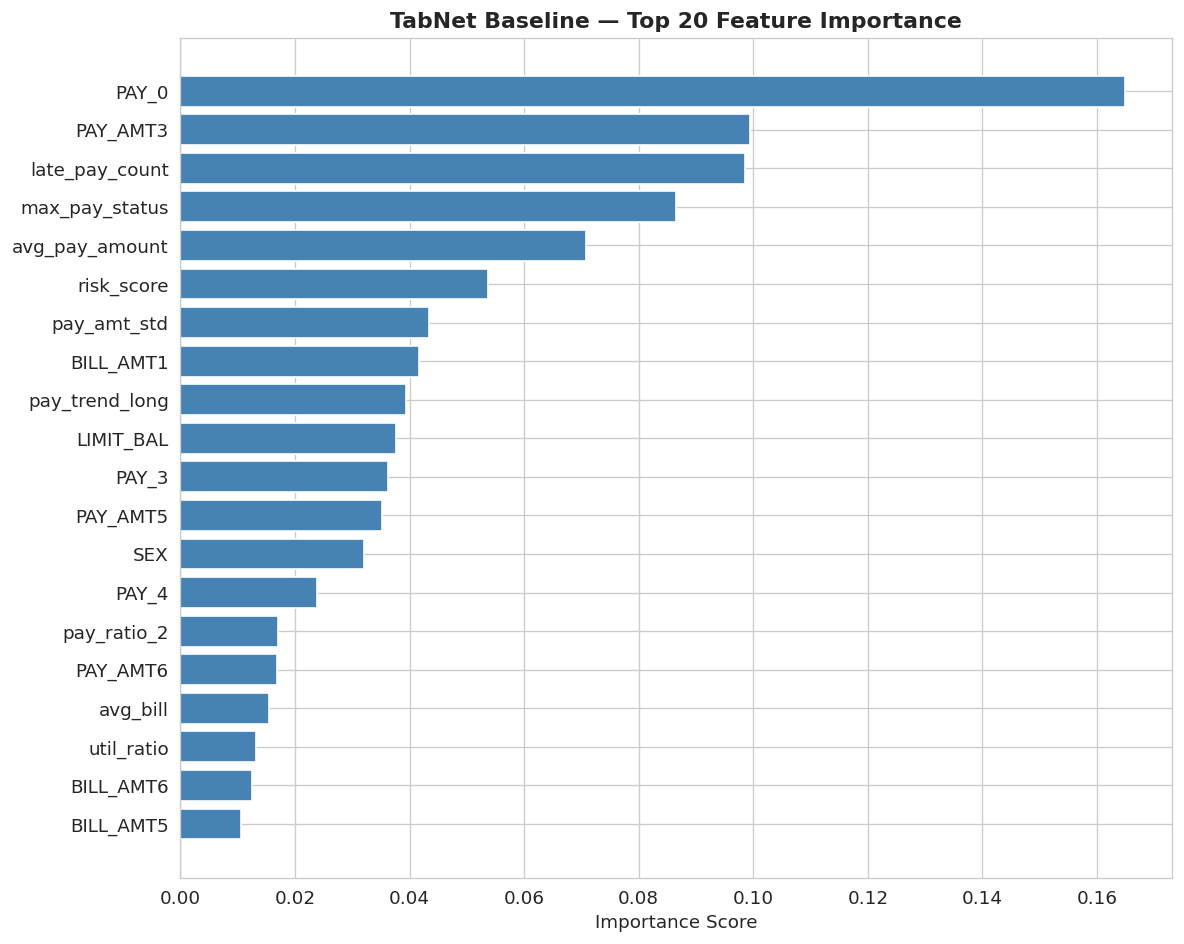


Top 10 features:
       feature  importance
         PAY_0    0.164906
      PAY_AMT3    0.099393
late_pay_count    0.098495
max_pay_status    0.086591
avg_pay_amount    0.070833
    risk_score    0.053765
   pay_amt_std    0.043383
     BILL_AMT1    0.041608
pay_trend_long    0.039295
     LIMIT_BAL    0.037663


In [11]:
# TabNet built-in feature importance
# Shows which features TabNet focused on during training

importance = baseline_tabnet.feature_importances_

# Sort by importance
feat_imp = pd.DataFrame({
    'feature':    feature_names,
    'importance': importance
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feat_imp['feature'][:20], feat_imp['importance'][:20],
         color='steelblue')
plt.title('TabNet Baseline — Top 20 Feature Importance',
          fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('results/figures/15_tabnet_baseline_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 features:")
print(feat_imp.head(10).to_string(index=False))

In [13]:
# Optuna searches best TabNet hyperparameters
# Val set used for scoring each trial
# 50 trials with TPE sampler

def objective(trial):
    n_d           = trial.suggest_categorical('n_d',       [16, 32, 64, 128])
    n_steps       = trial.suggest_int('n_steps',            3, 7)        # was 3-10
    gamma         = trial.suggest_float('gamma',            1.0, 2.0)
    n_independent = trial.suggest_int('n_independent',      1, 3)        # was 1-5
    n_shared      = trial.suggest_int('n_shared',           1, 3)        # was 1-5
    momentum      = trial.suggest_float('momentum',         0.01, 0.4)
    lambda_sparse = trial.suggest_float('lambda_sparse',   1e-6, 1e-2, log=True)
    lr            = trial.suggest_float('lr',               1e-3, 5e-2, log=True)
    batch_size    = trial.suggest_categorical('batch_size', [1024, 2048]) # removed 512

    model = TabNetClassifier(
        n_d              = n_d,
        n_a              = n_d,
        n_steps          = n_steps,
        gamma            = gamma,
        n_independent    = n_independent,
        n_shared         = n_shared,
        momentum         = momentum,
        lambda_sparse    = lambda_sparse,
        clip_value       = 2,
        optimizer_fn     = torch.optim.Adam,
        optimizer_params = {'lr': lr},
        scheduler_fn     = torch.optim.lr_scheduler.StepLR,
        scheduler_params = {'step_size': 10, 'gamma': 0.9},
        device_name      = device,
        verbose          = 0
    )

    model.fit(
        X_train            = X_train_sc,
        y_train            = y_train,
        eval_set           = [(X_val_sc, y_val)],
        eval_metric        = ['auc'],
        max_epochs         = 50,        # was 100
        patience           = 7,         # was 10
        weights            = 1,
        batch_size         = batch_size,
        virtual_batch_size = batch_size // 8
    )

    val_probs = model.predict_proba(X_val_sc)[:, 1]
    return roc_auc_score(y_val, val_probs)


def print_callback(study, trial):
    print(f"Trial {trial.number+1:>3}/50 | "
          f"AUC: {trial.value:.4f} | "
          f"Best: {study.best_value:.4f} | "
          f"n_d={trial.params['n_d']}, "
          f"steps={trial.params['n_steps']}, "
          f"lr={trial.params['lr']:.2e}, "
          f"batch={trial.params['batch_size']}")


study_tabnet = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42)
)
study_tabnet.optimize(
    objective,
    n_trials=50,
    callbacks=[print_callback]
)

print(f"\n{'='*50}")
print(f"Best Val AUC: {study_tabnet.best_value:.4f}")
print(f"Best params:")
for k, v in study_tabnet.best_params.items():
    print(f"  {k}: {v}")
print(f"{'='*50}")


Early stopping occurred at epoch 46 with best_epoch = 39 and best_val_0_auc = 0.75769
Trial   1/50 | AUC: 0.7577 | Best: 0.7577 | n_d=32, steps=3, lr=1.08e-03, batch=1024

Early stopping occurred at epoch 33 with best_epoch = 26 and best_val_0_auc = 0.76519
Trial   2/50 | AUC: 0.7652 | Best: 0.7652 | n_d=128, steps=5, lr=4.19e-03, batch=2048

Early stopping occurred at epoch 23 with best_epoch = 16 and best_val_0_auc = 0.75962
Trial   3/50 | AUC: 0.7596 | Best: 0.7652 | n_d=64, steps=6, lr=3.29e-03, batch=2048

Early stopping occurred at epoch 18 with best_epoch = 11 and best_val_0_auc = 0.74425
Trial   4/50 | AUC: 0.7442 | Best: 0.7652 | n_d=64, steps=7, lr=2.06e-03, batch=1024

Early stopping occurred at epoch 32 with best_epoch = 25 and best_val_0_auc = 0.78461
Trial   5/50 | AUC: 0.7846 | Best: 0.7846 | n_d=16, steps=3, lr=2.56e-02, batch=1024

Early stopping occurred at epoch 13 with best_epoch = 6 and best_val_0_auc = 0.7609
Trial   6/50 | AUC: 0.7609 | Best: 0.7846 | n_d=64, st

In [15]:
# Train final model using best hyperparameters from Optuna
# Use more epochs and more patience than Optuna trials
# Val set monitors training, test set saved for final evaluation

best_params = study_tabnet.best_params

final_tabnet = TabNetClassifier(
    n_d              = best_params['n_d'],
    n_a              = best_params['n_d'],
    n_steps          = best_params['n_steps'],
    gamma            = best_params['gamma'],
    n_independent    = best_params['n_independent'],
    n_shared         = best_params['n_shared'],
    momentum         = best_params['momentum'],
    lambda_sparse    = best_params['lambda_sparse'],
    clip_value       = 2,
    optimizer_fn     = torch.optim.Adam,
    optimizer_params = {'lr': best_params['lr']},
    scheduler_fn     = torch.optim.lr_scheduler.StepLR,
    scheduler_params = {'step_size': 10, 'gamma': 0.9},
    device_name      = device,
    verbose          = 10
)

final_tabnet.fit(
    X_train            = X_train_sc,
    y_train            = y_train,
    eval_set           = [(X_val_sc, y_val)],
    eval_metric        = ['auc'],
    max_epochs         = 200,
    patience           = 20,
    weights            = 1,
    batch_size         = best_params['batch_size'],
    virtual_batch_size = best_params['batch_size'] // 8
)

val_probs = final_tabnet.predict_proba(X_val_sc)[:, 1]
val_auc   = roc_auc_score(y_val, val_probs)
print(f"\nFinal TabNet Val AUC: {val_auc:.4f}")

epoch 0  | loss: 1.26994 | val_0_auc: 0.70625 |  0:00:04s
epoch 10 | loss: 0.57072 | val_0_auc: 0.7788  |  0:00:20s
epoch 20 | loss: 0.55889 | val_0_auc: 0.77904 |  0:00:33s
epoch 30 | loss: 0.55306 | val_0_auc: 0.78393 |  0:00:46s
epoch 40 | loss: 0.56073 | val_0_auc: 0.77731 |  0:01:03s

Early stopping occurred at epoch 49 with best_epoch = 29 and best_val_0_auc = 0.7867

Final TabNet Val AUC: 0.7867


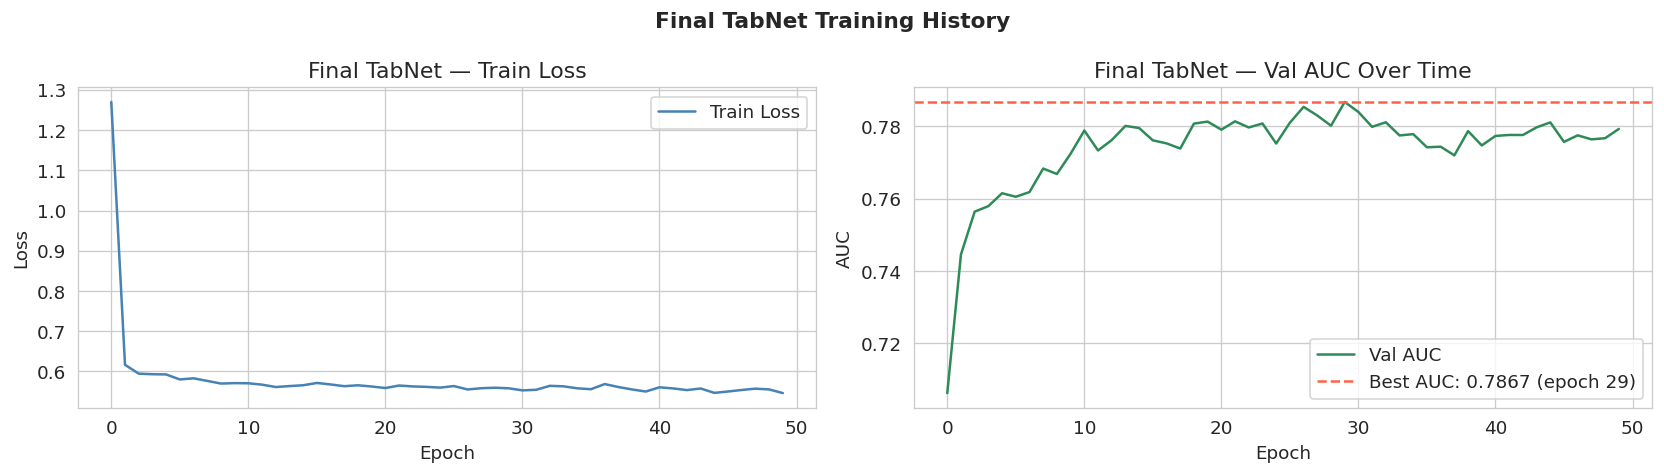

Best Val AUC: 0.7867 at epoch 29
Final epoch loss: 0.5463


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

history = final_tabnet.history.history

# Train loss curve
axes[0].plot(history['loss'], label='Train Loss', color='steelblue')
axes[0].set_title('Final TabNet — Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Val AUC curve
val_auc_history = [float(x) for x in history['val_0_auc']]
best_auc = max(val_auc_history)
best_ep  = val_auc_history.index(best_auc)

axes[1].plot(val_auc_history, color='seagreen', label='Val AUC')
axes[1].axhline(y=best_auc, color='tomato', linestyle='--',
                label=f'Best AUC: {best_auc:.4f} (epoch {best_ep})')
axes[1].set_title('Final TabNet — Val AUC Over Time')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()

plt.suptitle('Final TabNet Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/16_tabnet_final_training.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Best Val AUC: {best_auc:.4f} at epoch {best_ep}")
print(f"Final epoch loss: {history['loss'][-1]:.4f}")

In [16]:
# First and only time test set is used
# Honest final score for notebook 04

test_probs  = final_tabnet.predict_proba(X_test_sc)[:, 1]
test_auc    = roc_auc_score(y_test, test_probs)

# Find best threshold on val set, apply to test
fpr, tpr, thresholds = roc_curve(y_val, val_probs)
best_thresh  = thresholds[np.argmax(tpr - fpr)]
test_binary  = (test_probs >= best_thresh).astype(int)
cm           = confusion_matrix(y_test, test_binary)
tn, fp, fn, tp = cm.ravel()

print(f"\n{'='*50}")
print(f"  Final TabNet — Test Set Results")
print(f"{'='*50}")
print(f"  AUC:       {test_auc:.4f}")
print(f"  TP:        {tp}  (caught defaults)")
print(f"  FP:        {fp}  (false alarms)")
print(f"  FN:        {fn}  (missed defaults)")
print(f"  TN:        {tn}")
print(f"  Recall:    {tp/(tp+fn):.1%}")
print(f"  Threshold: {best_thresh:.3f}")
print(f"{'='*50}")

# Compare vs all previous results
print(f"\n{'='*60}")
print(f"{'Model':<30} {'AUC':>8} {'Recall':>8} {'FP':>6} {'FN':>6}")
print(f"{'='*60}")
print(f"{'Baseline Ensemble (NB02)':<30} {'0.7598':>8} {'66.5%':>8} {'831':>6} {'333':>6}")
print(f"{'DL Final Model (NB03)':<30} {'0.7597':>8} {'68.6%':>8} {'989':>6} {'312':>6}")
print(f"{'TabNet Final (NB04)':<30} {test_auc:>8.4f} {tp/(tp+fn):>8.1%} {fp:>6} {fn:>6}")
print(f"{'='*60}")

beat = "✅ BEAT" if test_auc > 0.7598 else "❌ NOT YET"
print(f"\nBaseline target 0.7598 → {beat}")


  Final TabNet — Test Set Results
  AUC:       0.7744
  TP:        660  (caught defaults)
  FP:        870  (false alarms)
  FN:        335  (missed defaults)
  TN:        2635
  Recall:    66.3%
  Threshold: 0.468

Model                               AUC   Recall     FP     FN
Baseline Ensemble (NB02)         0.7598    66.5%    831    333
DL Final Model (NB03)            0.7597    68.6%    989    312
TabNet Final (NB04)              0.7744    66.3%    870    335

Baseline target 0.7598 → ✅ BEAT


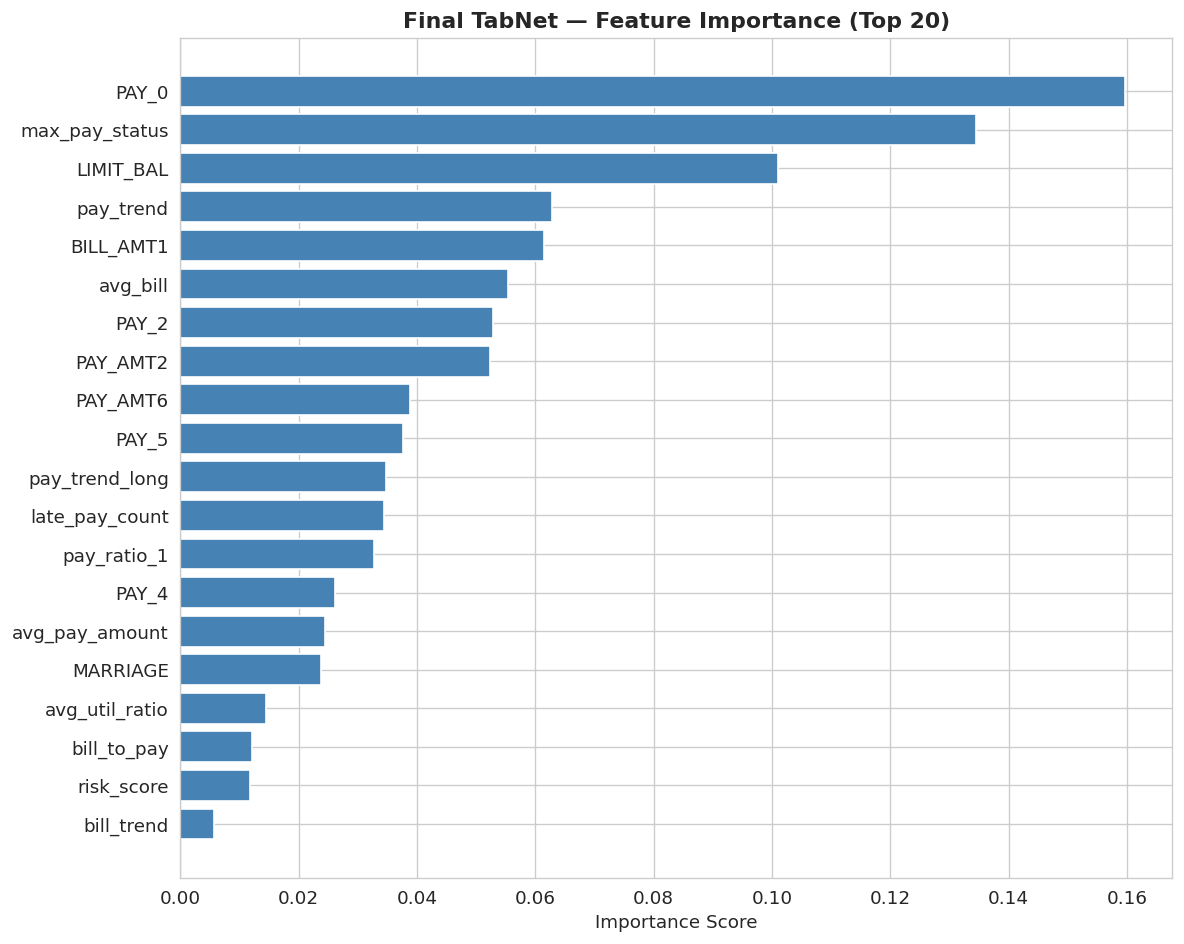


Top 15 features:
       feature  importance
         PAY_0    0.159678
max_pay_status    0.134538
     LIMIT_BAL    0.101037
     pay_trend    0.062822
     BILL_AMT1    0.061461
      avg_bill    0.055432
         PAY_2    0.052889
      PAY_AMT2    0.052320
      PAY_AMT6    0.038836
         PAY_5    0.037538
pay_trend_long    0.034821
late_pay_count    0.034403
   pay_ratio_1    0.032669
         PAY_4    0.026121
avg_pay_amount    0.024470

Engineered features in top 10:
  ['max_pay_status', 'pay_trend', 'avg_bill']
  3/10 are engineered features


In [26]:
# TabNet built-in feature importance after full training
# Shows which features the model focused on most

importance = final_tabnet.feature_importances_

feat_imp = pd.DataFrame({
    'feature':    feature_names,
    'importance': importance
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Plot top 20
plt.figure(figsize=(10, 8))
plt.barh(feat_imp['feature'][:20],
         feat_imp['importance'][:20],
         color='steelblue', edgecolor='white')
plt.title('Final TabNet — Feature Importance (Top 20)',
          fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('results/figures/17_tabnet_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 15 features:")
print(feat_imp.head(15).to_string(index=False))

print(f"\nEngineered features in top 10:")
engineered = ['late_pay_count', 'max_pay_status', 'pay_trend',
              'pay_trend_long', 'avg_bill', 'avg_pay_amount',
              'bill_std', 'pay_amt_std', 'util_ratio',
              'avg_util_ratio', 'pay_ratio_1', 'pay_ratio_2',
              'bill_to_pay', 'risk_score', 'bill_trend',
              'bill_trend_long', 'pay_amt_trend']
top10 = feat_imp['feature'][:10].tolist()
eng_in_top10 = [f for f in top10 if f in engineered]
print(f"  {eng_in_top10}")
print(f"  {len(eng_in_top10)}/10 are engineered features")

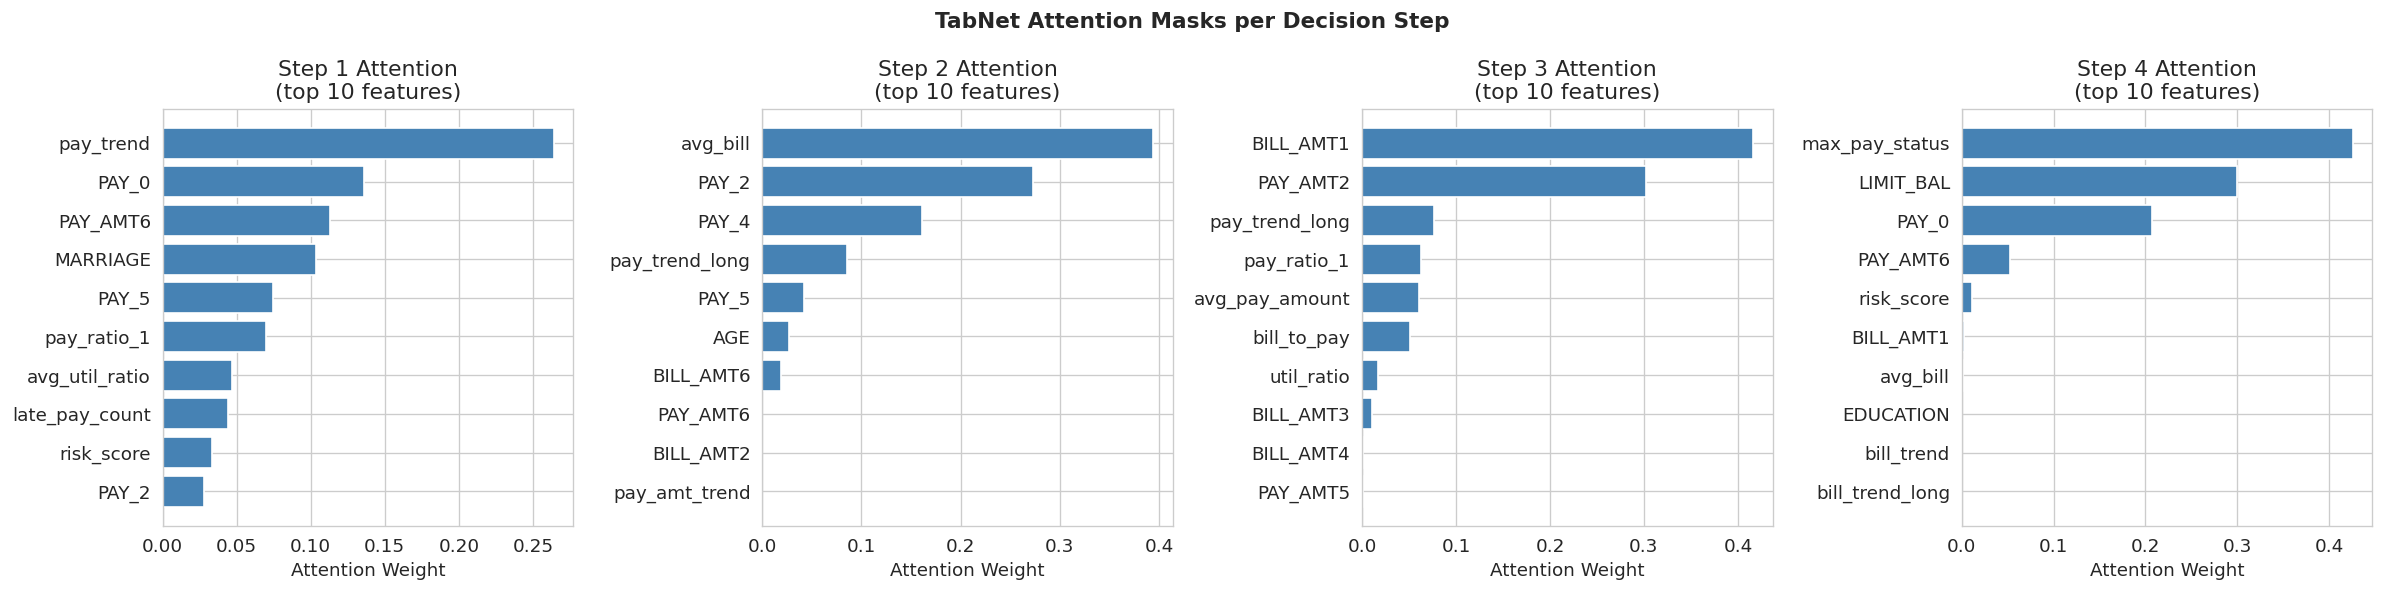

In [27]:
# TabNet explain() shows attention masks per decision step
# Each step focuses on different features
# This is TabNet's built-in local explanation

# Get attention masks for a sample of test data
explain_matrix, masks = final_tabnet.explain(X_test_sc[:500])

fig, axes = plt.subplots(1, best_params['n_steps'],
                          figsize=(5 * best_params['n_steps'], 5))

if best_params['n_steps'] == 1:
    axes = [axes]

for step, ax in enumerate(axes):
    step_importance = masks[step].mean(axis=0)
    top_idx  = np.argsort(step_importance)[::-1][:10]
    top_feat = [feature_names[i] for i in top_idx]
    top_vals = step_importance[top_idx]

    ax.barh(top_feat, top_vals, color='steelblue', edgecolor='white')
    ax.set_title(f'Step {step+1} Attention\n(top 10 features)')
    ax.set_xlabel('Attention Weight')
    ax.invert_yaxis()

plt.suptitle('TabNet Attention Masks per Decision Step',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/18_tabnet_attention_steps.png',
            dpi=150, bbox_inches='tight')
plt.show()

# 📋 Notebook 04 — TabNet Summary

## Final Results (Test Set — Unseen Data)

| Model | AUC | Recall | TP | FP | FN |
|---|---|---|---|---|---|
| Baseline Ensemble (NB02) | 0.7598 | 66.5% | 662 | 831 | 333 |
| DL Final Model (NB03) | 0.7597 | 68.6% | 683 | 989 | 312 |
| **TabNet Final (NB04)** | **0.7744** | **66.3%** | **660** | **870** | **335** |

> TabNet beats baseline ensemble AUC by +0.0146 with no resampling.

---

## Why TabNet Won

| Problem in NB03 | TabNet Solution |
|---|---|
| NearMiss → 6,600 samples | Full 17,850 training samples |
| Custom MLP overfit fast | Sparse attention = built-in regularization |
| Val loss exploded epoch 1 | Stable training throughout 50 epochs |
| Manual attention layer | Sequential attention steps (built-in) |

---

## TabNet Architecture Used

| Parameter | Value |
|---|---|
| n_d / n_a | 128 |
| n_steps | 4 |
| gamma | 1.114 |
| n_independent | 2 |
| n_shared | 2 |
| momentum | 0.264 |
| lambda_sparse | 1.99e-04 |
| learning rate | 3.47e-02 |
| batch size | 1024 |

---

## What Each Attention Step Learned

| Step | Focus | Top Feature |
|---|---|---|
| Step 1 | Payment behavior trends | pay_trend (0.25) |
| Step 2 | Bill amounts and history | avg_bill (0.40) |
| Step 3 | Recent transaction details | BILL_AMT1 (0.42) |
| Step 4 | Overall risk profile | max_pay_status (0.43) |

Each step specializes in a different aspect of credit risk,
mimicking how a loan officer reviews an application.

---

## Feature Engineering Impact

- **3/10 top features are engineered** (max_pay_status, pay_trend, avg_bill)
- Engineered features captured domain knowledge the model couldn't learn alone
- `max_pay_status` ranked #2 overall (0.135 importance)
- `pay_trend` ranked #4 overall (0.063 importance)

---

## Key Lessons

1. **Architecture matters less than data quality**
   - TabNet with full data beat custom MLP with NearMiss
   - 17,850 samples >> 6,600 boundary samples

2. **Purpose-built architectures outperform custom ones**
   - TabNet designed for tabular data beat our hand-crafted MLP
   - No need for complex custom attention mechanisms

3. **Sparse attention is powerful for credit data**
   - Each step focuses on different risk dimensions
   - Naturally interpretable without external libraries

4. **Class weights > resampling for DL**
   - No resampling needed with proper class weighting
   - Avoids overfitting on boundary samples

---

## Optuna Tuning Impact

| Stage | Val AUC |
|---|---|
| TabNet baseline (default params) | 0.7784 |
| After Optuna (50 trials) | 0.7867 |
| Final model test AUC | 0.7744 |

---

## References

- Arik, S. O., & Pfister, T. (2021). TabNet: Attentive Interpretable
  Tabular Learning. AAAI 2021. https://arxiv.org/abs/1908.07442
- Wang, S., & Zhang, X. (2024). Credit Default Prediction Based on
  TabNet-Stacking. Entropy, 26(10), 861.
  https://doi.org/10.3390/e26100861